# Analisis Model Segmentasi Produk — Bengkel Yudi Motor
**Preprocessing → PCA → K-Means Clustering → ABC Analysis → Matriks Rekomendasi**

Notebook ini menjalankan **kode yang sama persis dengan sistem** (modul `app/services/`), bukan kode terpisah.
Tujuannya: (1) menampilkan setiap tahap beserta grafik untuk BAB IV, dan (2) menjadi bukti bahwa angka di skripsi
berasal langsung dari implementasi sistem.

Setiap grafik juga otomatis disimpan sebagai file PNG resolusi tinggi di folder `notebooks/grafik/`
sehingga bisa langsung dimasukkan ke dokumen skripsi.

**Cara menjalankan:** buka file ini di VS Code → pilih kernel `TAgekani` (pojok kanan atas) → klik **Run All**.

In [1]:
# ============================================================
# 0. SETUP — import modul sistem & pengaturan grafik
# ============================================================
import os, sys, logging
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Cari folder backend (folder yang berisi 'app/') supaya modul sistem bisa di-import
BACKEND = Path.cwd()
while not (BACKEND / 'app').exists() and BACKEND != BACKEND.parent:
    BACKEND = BACKEND.parent
sys.path.insert(0, str(BACKEND))
logging.disable(logging.CRITICAL)   # sembunyikan log INFO agar output rapi

# === Modul SISTEM (kode yang sama dengan backend) ===
from app.services import preprocessing, kmeans, labeling, abc_analysis, decision_rules

DATASET = BACKEND / 'sample_data' / 'dataPenjualanYudiMotor_2021-2025_FINAL.csv'
GRAFIK = BACKEND / 'notebooks' / 'grafik'
GRAFIK.mkdir(parents=True, exist_ok=True)

# --- Gaya grafik (latar terang, garis bantu tipis, tanpa bingkai atas/kanan)
TINTA, TINTA2, REDUP, GRID, SUMBU = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'savefig.facecolor': '#fcfcfb',
    'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 10,
    'axes.edgecolor': SUMBU, 'axes.labelcolor': TINTA2, 'axes.titlecolor': TINTA,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'xtick.color': REDUP, 'ytick.color': REDUP, 'legend.frameon': False,
})
# Warna tetap per kondisi penjualan (warna mengikuti entitas, bukan urutan)
WARNA_KONDISI = {'Produk Harian': '#2a78d6', 'Produk Langka': '#eb6834',
                 'Produk Andalan': '#1baf7a', 'Produk Premium': '#eda100'}
URUTAN_KONDISI = list(WARNA_KONDISI)
WARNA_ABC = {'A': '#184f95', 'B': '#3987e5', 'C': '#86b6ef'}     # biru gelap -> terang (ordinal)
BIRU_SEQ = LinearSegmentedColormap.from_list('biru', ['#f4f8fe', '#9ec5f4', '#3987e5', '#184f95', '#0d366b'])
DIVERGING = LinearSegmentedColormap.from_list('div', ['#184f95', '#6da7ec', '#f0efec', '#e8876b', '#b3261e'])

def simpan(fig, nama):
    fig.tight_layout()
    fig.savefig(GRAFIK / f'{nama}.png', bbox_inches='tight')
    plt.show()

rupiah = lambda x: f"Rp{x:,.0f}".replace(',', '.')
print('Backend :', BACKEND)
print('Dataset :', DATASET.name)

Backend : /home/claude/ta2/TugasAkhir7smtAstungkarafix/backend
Dataset : dataPenjualanYudiMotor_2021-2025_FINAL.csv


## 1. Profil Data Mentah
Satu baris data = **satu jenis barang pada satu nota**. Satu nota (`no_invoice`) dapat berisi beberapa baris.

In [2]:
raw = pd.read_csv(DATASET)
raw['tanggal_dt'] = pd.to_datetime(raw['tanggal'], dayfirst=True)
raw['tahun'] = raw['tanggal_dt'].dt.year

profil = pd.DataFrame({
    'Aspek': ['Jumlah baris (item penjualan)', 'Jumlah transaksi (invoice unik)', 'Jumlah produk (sub_kategori)',
              'Jumlah kategori', 'Missing value', 'Baris duplikat', 'total_sales negatif',
              'Rentang periode', 'Total unit terjual', 'Total pendapatan'],
    'Nilai': [f"{len(raw):,}", f"{raw.no_invoice.nunique():,}", raw.sub_kategori.nunique(), raw.kategori.nunique(),
              int(raw.drop(columns=['tanggal_dt','tahun']).isna().sum().sum()), int(raw.drop(columns=['tanggal_dt','tahun']).duplicated().sum()),
              int((raw.total_sales < 0).sum()),
              f"{raw.tanggal_dt.min():%d-%m-%Y} s.d. {raw.tanggal_dt.max():%d-%m-%Y}",
              f"{raw.kuantitas_terjual.sum():,}", rupiah(raw.total_sales.sum())],
})
display(profil.style.hide(axis='index'))

per_tahun = raw.groupby('tahun').agg(baris_item=('no_invoice', 'size'), transaksi=('no_invoice', 'nunique'),
                                     pendapatan=('total_sales', 'sum'))
display(per_tahun.style.format({'baris_item': '{:,}', 'transaksi': '{:,}', 'pendapatan': rupiah}))

Aspek,Nilai
Jumlah baris (item penjualan),"66,865"
Jumlah transaksi (invoice unik),"24,540"
Jumlah produk (sub_kategori),126
Jumlah kategori,24
Missing value,0
Baris duplikat,0
total_sales negatif,0
Rentang periode,01-01-2021 s.d. 31-12-2025
Total unit terjual,"517,409"
Total pendapatan,Rp41.198.092.500


,baris_item,transaksi,pendapatan
tahun,,,
2021,"7,633","2,833",Rp4.340.426.000
2022,"12,966","4,820",Rp7.585.882.000
2023,"15,485","5,639",Rp9.478.691.000
2024,"13,732","5,024",Rp8.617.861.500
2025,"17,049","6,224",Rp11.175.232.000


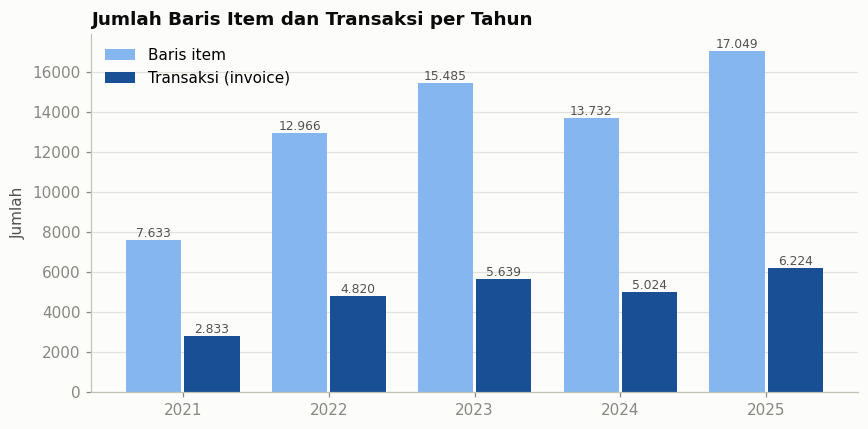

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(per_tahun)); w = 0.38
b1 = ax.bar(x - w/2 - 0.01, per_tahun['baris_item'], w, color='#86b6ef', label='Baris item')
b2 = ax.bar(x + w/2 + 0.01, per_tahun['transaksi'], w, color='#184f95', label='Transaksi (invoice)')
for bars in (b1, b2):
    for r in bars:
        ax.text(r.get_x() + r.get_width()/2, r.get_height(), f"{int(r.get_height()):,}".replace(',', '.'),
                ha='center', va='bottom', fontsize=8, color=TINTA2)
ax.set_xticks(x, per_tahun.index); ax.set_ylabel('Jumlah'); ax.grid(axis='x', visible=False)
ax.set_title('Jumlah Baris Item dan Transaksi per Tahun'); ax.legend(loc='upper left')
simpan(fig, '01_transaksi_per_tahun')

## 2. Preprocessing: Agregasi & Feature Engineering
Fungsi sistem `preprocessing.aggregate_data()` menjalankan seluruh tahap (Gambar 3.15):
pembersihan → agregasi per produk → 5 fitur → winsorizing → transformasi log → standarisasi → PCA.

In [4]:
df = preprocessing.aggregate_data(str(DATASET), tahun_awal=2021, tahun_akhir=2025)
FITUR = preprocessing.CLUSTER_FEATURES

print(f"Baris setelah cleaning : {df.attrs['n_transaksi_setelah_cleaning']:,}")
print(f"Duplikat / missing / negatif dihapus : {df.attrs['n_duplikat_dihapus']} / {df.attrs['n_missing_dihapus']} / {df.attrs['n_negatif_dihapus']}")
print(f"Transaksi (invoice) : {df.attrs['n_invoice']:,}")
print(f"Produk unik : {len(df)}")
print(f"Batas winsorizing : P{preprocessing.WINSORIZE_LOWER*100:.0f} - P{preprocessing.WINSORIZE_UPPER*100:.0f}")

contoh = ['Castrol Pro 2T', 'BUSI YGP U22FSU', 'AHM K44 Scoopy', 'Aki Kering YGP 3C1', 'Aki Kering GS ASTRA GTZ7V']
display(df.set_index('produk').loc[contoh, FITUR + ['total_pendapatan', 'pc1_scaled', 'pc2_scaled']]
        .style.format({'avg_qty_per_transaksi': '{:.2f}', 'avg_harga': rupiah, 'total_pendapatan': rupiah,
                       'pc1_scaled': '{:.4f}', 'pc2_scaled': '{:.4f}'}))

Baris setelah cleaning : 66,865
Duplikat / missing / negatif dihapus : 0 / 0 / 0
Transaksi (invoice) : 24,540
Produk unik : 126
Batas winsorizing : P17 - P83


,frekuensi_transaksi,avg_qty_per_transaksi,total_kuantitas,avg_harga,n_bulan_aktif,total_pendapatan,pc1_scaled,pc2_scaled
produk,,,,,,,,
Castrol Pro 2T,730,14.23,10389,Rp37.641,60,Rp391.603.500,-2.4936,1.2679
BUSI YGP U22FSU,1280,5.75,7366,Rp15.795,60,Rp116.572.500,-1.7490,1.6368
AHM K44 Scoopy,441,6.21,2737,Rp103.347,60,Rp283.564.500,-0.4625,-0.6531
Aki Kering YGP 3C1,263,5.41,1422,Rp217.156,59,Rp307.707.000,2.2207,0.0729
Aki Kering GS ASTRA GTZ7V,302,2.62,790,Rp332.891,60,Rp264.140.500,1.9750,-0.2018


In [5]:
# Statistik deskriptif 5 fitur (nilai asli, sebelum transformasi)
display(df[FITUR].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].style.format('{:,.2f}'))

,mean,std,min,25%,50%,75%,max
frekuensi_transaksi,530.67,285.21,43.00,317.00,447.00,702.00,"1,360.00"
avg_qty_per_transaksi,7.00,3.10,2.55,4.88,6.21,8.30,14.25
total_kuantitas,"4,106.42","3,071.48",135.00,"1,378.75","3,081.50","6,108.50","10,389.00"
avg_harga,"181,852.00","289,234.61","5,550.67","51,603.50","88,424.68","215,542.23","1,728,760.42"
n_bulan_aktif,58.44,5.57,30.00,59.00,60.00,60.00,60.00


### 2.1 Korelasi antar fitur
Dasar seleksi fitur: tidak ada pasangan dengan korelasi mendekati sempurna (|r| > 0,95), sehingga tidak ada fitur yang redundan.

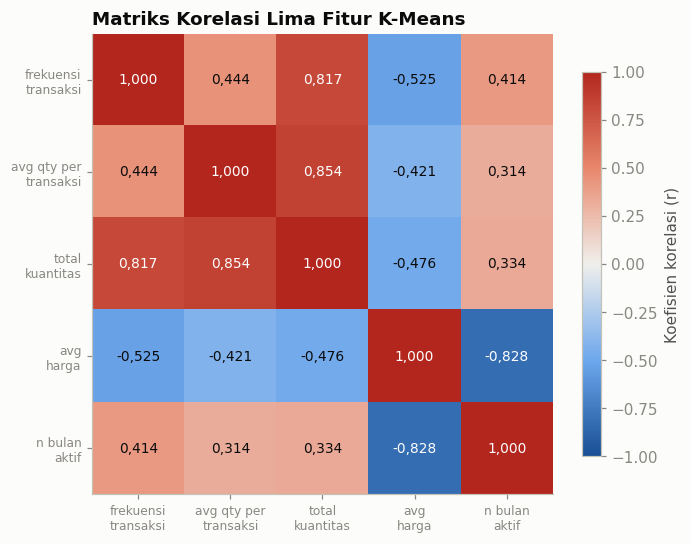

In [6]:
korelasi = df[FITUR].corr()
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(korelasi, cmap=DIVERGING, vmin=-1, vmax=1)
label = ['frekuensi\ntransaksi', 'avg qty per\ntransaksi', 'total\nkuantitas', 'avg\nharga', 'n bulan\naktif']
ax.set_xticks(range(5), label, fontsize=8); ax.set_yticks(range(5), label, fontsize=8); ax.grid(False)
for i in range(5):
    for j in range(5):
        v = korelasi.iloc[i, j]
        ax.text(j, i, f"{v:.3f}".replace('.', ','), ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 else TINTA)
fig.colorbar(im, ax=ax, shrink=0.8, label='Koefisien korelasi (r)')
ax.set_title('Matriks Korelasi Lima Fitur K-Means')
simpan(fig, '02_korelasi_fitur')

### 2.2 Efek winsorizing + transformasi log
Distribusi fitur sebelum dan sesudah transformasi (keduanya distandarisasi agar bisa dibandingkan dalam satu skala).

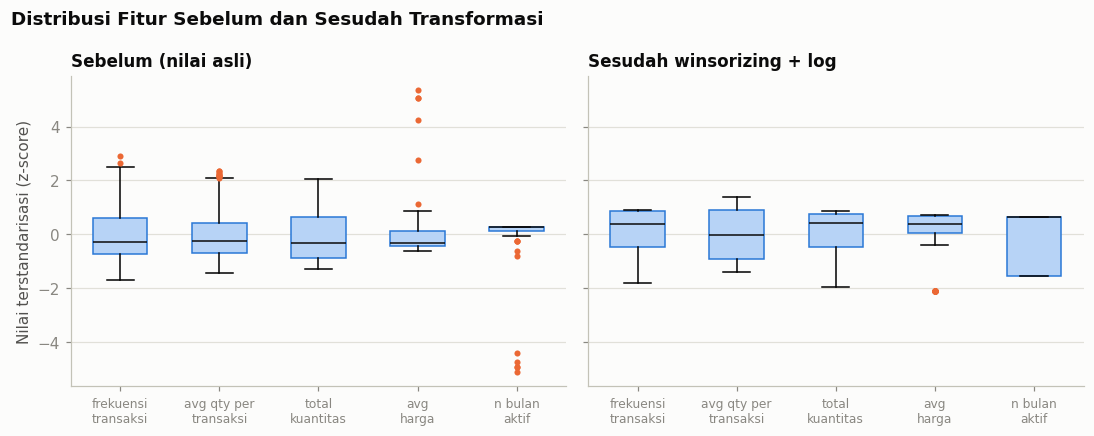

In [7]:
X_asli = df[FITUR].copy()
X_trans = X_asli.copy()
for c in FITUR:
    lo, hi = X_trans[c].quantile([preprocessing.WINSORIZE_LOWER, preprocessing.WINSORIZE_UPPER])
    X_trans[c] = X_trans[c].clip(lo, hi)
    X_trans[c] = np.log1p(X_trans[c] - X_trans[c].min() + 1)
z = lambda d: (d - d.mean()) / d.std(ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, data, judul in [(axes[0], z(X_asli), 'Sebelum (nilai asli)'), (axes[1], z(X_trans), 'Sesudah winsorizing + log')]:
    bp = ax.boxplot([data[c] for c in FITUR], patch_artist=True, widths=0.55,
                    medianprops=dict(color=TINTA), flierprops=dict(marker='o', markersize=4, markerfacecolor='#eb6834', markeredgecolor='none'))
    for p in bp['boxes']: p.set(facecolor='#b7d3f6', edgecolor='#2a78d6')
    ax.set_xticks(range(1, 6), label, fontsize=8); ax.set_title(judul, fontsize=11); ax.grid(axis='x', visible=False)
axes[0].set_ylabel('Nilai terstandarisasi (z-score)')
fig.suptitle('Distribusi Fitur Sebelum dan Sesudah Transformasi', x=0.01, ha='left', fontweight='bold', color=TINTA)
simpan(fig, '03_efek_winsorizing')

## 3. Uji Sensitivitas Batas Winsorizing (bukti pemilihan P17–P83)
Seluruh pipeline sistem dijalankan ulang untuk batas persentil P5–P95 sampai P30–P70.
Untuk setiap batas dicatat K optimal (Silhouette tertinggi), nilai Silhouette, dan ukuran klaster.

**Kriteria pemilihan:** batas **paling longgar** (memotong data paling sedikit) yang sudah menghasilkan
segmentasi **stabil**: K optimal konsisten, tidak ada klaster yang terlalu kecil, dan Silhouette ≥ 0,51 (*reasonable structure*).

In [8]:
BATAS_ASLI = (preprocessing.WINSORIZE_LOWER, preprocessing.WINSORIZE_UPPER)
hasil = []
try:
    for p in range(5, 31):
        preprocessing.WINSORIZE_LOWER, preprocessing.WINSORIZE_UPPER = p / 100, 1 - p / 100
        d = preprocessing.aggregate_data(str(DATASET), 2021, 2025)
        opt = kmeans.find_optimal_k(d, ['pc1', 'pc2'])
        X = d[['pc1_scaled', 'pc2_scaled']].values
        lab, _, _ = kmeans._run_single_kmeans(X, opt['optimal_k'])
        ukuran = sorted(np.bincount(lab).tolist())
        hasil.append({'Batas': f'P{p}–P{100 - p}', 'p': p, 'K optimal': opt['optimal_k'],
                      'Silhouette': max(opt['silhouette_data']['scores']),
                      'Ukuran klaster': ', '.join(map(str, ukuran)),
                      'Klaster terkecil': min(ukuran), 'Terkecil (%)': min(ukuran) / len(d) * 100,
                      'Variansi PCA (%)': sum(d.attrs['pca_explained_variance'][:2]) * 100})
finally:
    preprocessing.WINSORIZE_LOWER, preprocessing.WINSORIZE_UPPER = BATAS_ASLI   # kembalikan ke nilai sistem

sens = pd.DataFrame(hasil)
display(sens.drop(columns='p').style.hide(axis='index')
        .format({'Silhouette': '{:.4f}', 'Terkecil (%)': '{:.0f}%', 'Variansi PCA (%)': '{:.1f}'})
        .apply(lambda r: ['background-color:#e2ede6; font-weight:bold' if r['Batas'] == 'P17–P83' else '' for _ in r], axis=1))

Batas,K optimal,Silhouette,Ukuran klaster,Klaster terkecil,Terkecil (%),Variansi PCA (%)
P5–P95,4,0.6179,"7, 7, 34, 78",7,6%,84.2
P6–P94,2,0.5953,"19, 107",19,15%,83.5
P7–P93,4,0.5797,"9, 11, 35, 71",9,7%,84.0
P8–P92,4,0.6312,"11, 13, 30, 72",11,9%,84.1
P9–P91,3,0.6387,"13, 32, 81",13,10%,83.9
P10–P90,3,0.6349,"13, 33, 80",13,10%,83.8
P11–P89,3,0.6253,"14, 33, 79",14,11%,83.6
P12–P88,3,0.6322,"16, 33, 77",16,13%,84.0
P13–P87,3,0.6375,"18, 34, 74",18,14%,84.0
P14–P86,3,0.6471,"18, 37, 71",18,14%,84.3


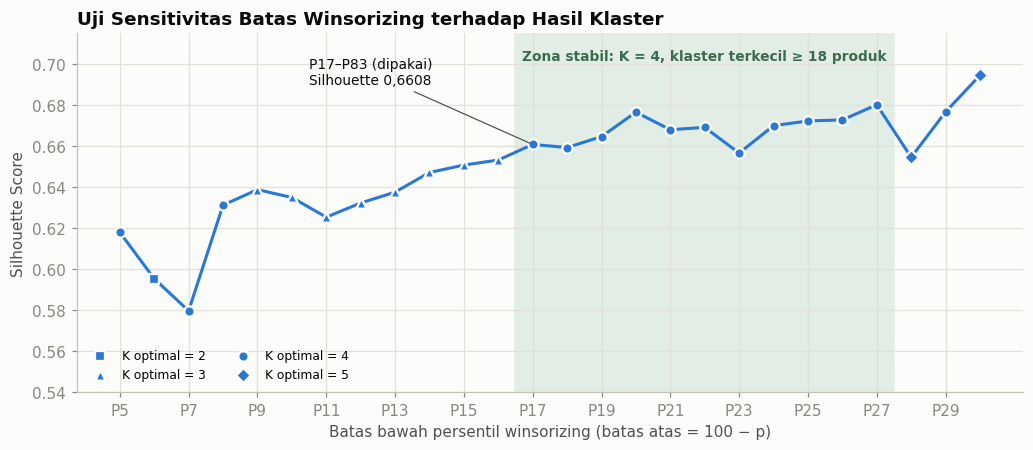

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
zona = sens[(sens.p >= 17) & (sens.p <= 27)]
ax.axvspan(16.5, 27.5, color='#e2ede6', zorder=0)
ax.text(22, 0.702, 'Zona stabil: K = 4, klaster terkecil ≥ 18 produk', ha='center', fontsize=9, color='#3d6b4f', fontweight='bold')
ax.plot(sens.p, sens.Silhouette, color='#2a78d6', lw=2, zorder=2)
for k, mk in [(2, 's'), (3, '^'), (4, 'o'), (5, 'D')]:
    s = sens[sens['K optimal'] == k]
    ax.scatter(s.p, s.Silhouette, marker=mk, s=46, color='#2a78d6', edgecolor='#fcfcfb', linewidth=1.5, zorder=3, label=f'K optimal = {k}')
sel = sens[sens.p == 17].iloc[0]
ax.annotate(f"P17–P83 (dipakai)\nSilhouette {sel.Silhouette:.4f}".replace('.', ','), (17, sel.Silhouette),
            xytext=(10.5, 0.69), fontsize=9, color=TINTA, arrowprops=dict(arrowstyle='-', color=TINTA2, lw=0.8))
ax.set_xticks(sens.p[::2], [f'P{p}' for p in sens.p[::2]])
ax.set_xlabel('Batas bawah persentil winsorizing (batas atas = 100 − p)'); ax.set_ylabel('Silhouette Score')
ax.set_ylim(0.54, 0.715); ax.legend(loc='lower left', ncol=2, fontsize=8)
ax.set_title('Uji Sensitivitas Batas Winsorizing terhadap Hasil Klaster')
simpan(fig, '04_sensitivitas_winsorizing')

**Cara membaca:** di bawah P17 hasil klaster **tidak stabil**. K optimal berpindah-pindah (2, 3, 4) dan pada beberapa batas
muncul klaster yang sangat kecil (7–13 produk). Mulai **P17** hingga P27, K optimal konsisten **4**, klaster terkecil selalu
sekitar 19–21 produk, dan Silhouette berada pada 0,66–0,68. **P17–P83 adalah batas paling longgar di zona stabil tersebut**,
sehingga dipilih karena memotong data paling sedikit tanpa mengorbankan stabilitas segmentasi.

## 4. Reduksi Dimensi (PCA)
Lima fitur terstandarisasi dipadatkan menjadi 2 komponen utama sebagai input K-Means.

Komponen,Variansi (%),Kumulatif (%)
Komponen 1,71.17,71.17
Komponen 2,12.97,84.14
Komponen 3,8.88,93.02
Komponen 4,4.60,97.62
Komponen 5,2.38,100.00


Bobot (loading) setiap fitur pada komponen utama:


,PC1,PC2
frekuensi_transaksi,-0.485,-0.048
avg_qty_per_transaksi,-0.442,-0.219
total_kuantitas,-0.495,-0.156
avg_harga,0.354,-0.918
n_bulan_aktif,-0.446,-0.287


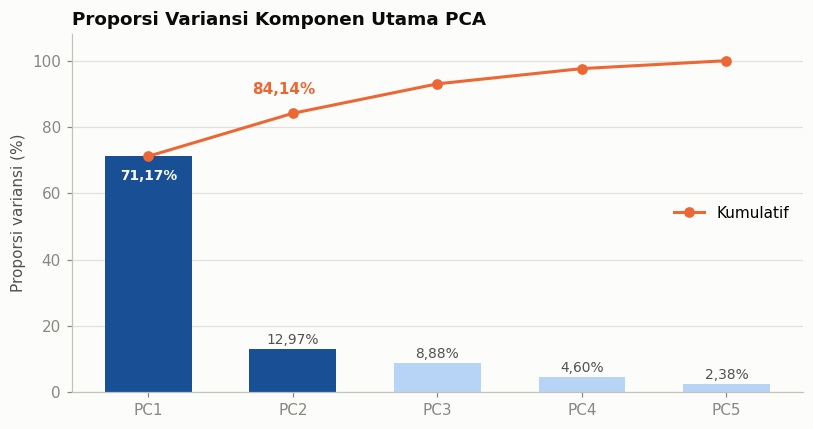

In [10]:
evr = np.array(df.attrs['pca_explained_variance']) * 100
tabel_pca = pd.DataFrame({'Komponen': [f'Komponen {i}' for i in range(1, 6)],
                          'Variansi (%)': evr, 'Kumulatif (%)': evr.cumsum()})
display(tabel_pca.style.hide(axis='index').format({'Variansi (%)': '{:.2f}', 'Kumulatif (%)': '{:.2f}'}))
loading = pd.DataFrame(df.attrs['pca_components'], index=FITUR, columns=['PC1', 'PC2'])
print('Bobot (loading) setiap fitur pada komponen utama:'); display(loading.style.format('{:.3f}'))

fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(range(1, 6), evr, color=['#184f95'] * 2 + ['#b7d3f6'] * 3, width=0.6)
ax.plot(range(1, 6), evr.cumsum(), color='#eb6834', marker='o', lw=2, markersize=6, label='Kumulatif')
for i, v in enumerate(evr):
    if i == 0: ax.text(1, v - 7, f'{v:.2f}%'.replace('.', ','), ha='center', fontsize=9, color='white', fontweight='bold')
    else: ax.text(i + 1, v + 1.5, f'{v:.2f}%'.replace('.', ','), ha='center', fontsize=9, color=TINTA2)
ax.annotate(f'{evr[:2].sum():.2f}%'.replace('.', ','), (2, evr[:2].sum()), xytext=(1.72, 90), fontsize=10, color='#eb6834', fontweight='bold')
ax.set_xticks(range(1, 6), [f'PC{i}' for i in range(1, 6)]); ax.set_ylim(0, 108); ax.grid(axis='x', visible=False)
ax.set_ylabel('Proporsi variansi (%)'); ax.legend(loc='center right')
ax.set_title('Proporsi Variansi Komponen Utama PCA')
simpan(fig, '05_pca_variansi')

## 5. Penentuan Jumlah Klaster: Elbow Method & Silhouette Score
K = 2 sampai 5 dievaluasi. K optimal = **Silhouette Score tertinggi**; WCSS (Elbow) sebagai evaluasi pendukung.

In [11]:
opt = kmeans.find_optimal_k(df, ['pc1', 'pc2'])
K_OPT = opt['optimal_k']
eval_k = pd.DataFrame({'K': opt['elbow_data']['k'], 'WCSS': opt['elbow_data']['wcss'], 'Silhouette': opt['silhouette_data']['scores']})
eval_k['Penurunan WCSS (%)'] = (-eval_k.WCSS.pct_change() * 100)
display(eval_k.style.hide(axis='index').format({'WCSS': '{:.2f}', 'Silhouette': '{:.4f}', 'Penurunan WCSS (%)': '{:.1f}'}, na_rep='–')
        .apply(lambda r: ['font-weight:bold; background-color:#e2ede6' if r.K == K_OPT else '' for _ in r], axis=1))
print(f'K optimal (Silhouette tertinggi) = {K_OPT}')

K,WCSS,Silhouette,Penurunan WCSS (%)
2,169.16,0.6060,–
3,73.33,0.6546,56.7
4,33.79,0.6608,53.9
5,19.53,0.6268,42.2


K optimal (Silhouette tertinggi) = 4


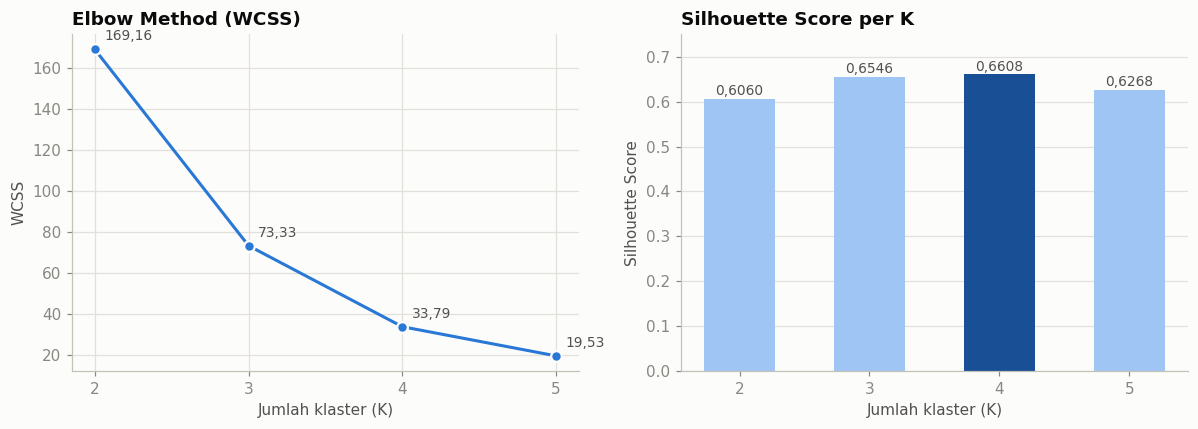

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(eval_k.K, eval_k.WCSS, color='#2a78d6', lw=2, marker='o', markersize=7, markeredgecolor='#fcfcfb', markeredgewidth=1.5)
for k, w in zip(eval_k.K, eval_k.WCSS): ax.annotate(f'{w:.2f}'.replace('.', ','), (k, w), xytext=(6, 6), textcoords='offset points', fontsize=9, color=TINTA2)
ax.set_xticks(eval_k.K); ax.set_xlabel('Jumlah klaster (K)'); ax.set_ylabel('WCSS'); ax.set_title('Elbow Method (WCSS)')
ax = axes[1]
warna = ['#184f95' if k == K_OPT else '#9ec5f4' for k in eval_k.K]
ax.bar(eval_k.K, eval_k.Silhouette, color=warna, width=0.55)
for k, s in zip(eval_k.K, eval_k.Silhouette): ax.text(k, s + 0.008, f'{s:.4f}'.replace('.', ','), ha='center', fontsize=9, color=TINTA2)
ax.set_xticks(eval_k.K); ax.set_ylim(0, 0.75); ax.set_xlabel('Jumlah klaster (K)'); ax.set_ylabel('Silhouette Score')
ax.grid(axis='x', visible=False); ax.set_title('Silhouette Score per K')
simpan(fig, '06_elbow_silhouette')

## 6. Hasil K-Means Clustering & Pelabelan Klaster
K-Means final dijalankan dengan K optimal, lalu setiap klaster diberi nama bisnis melalui pencocokan
centroid dengan 4 arketipe (`labeling.label_clusters()`).

In [13]:
df_km, centroid = kmeans.run_kmeans(df, ['pc1', 'pc2'], K_OPT)
df_lab = labeling.label_clusters(df_km, FITUR, centroid)
nama_klaster = df_lab.groupby('cluster')['kondisi_penjualan'].first()

profil_k = (df_lab.groupby('kondisi_penjualan')
            .agg(Jumlah_produk=('produk', 'size'), Frekuensi_transaksi=('frekuensi_transaksi', 'mean'),
                 Rata2_harga=('avg_harga', 'mean'), Bulan_aktif=('n_bulan_aktif', 'mean'), Total_pendapatan=('total_pendapatan', 'mean'))
            .reindex(URUTAN_KONDISI))
print('Karakteristik rata-rata tiap klaster (Tabel 4.16):')
display(profil_k.style.format({'Frekuensi_transaksi': '{:.1f}', 'Rata2_harga': rupiah, 'Bulan_aktif': '{:.1f}', 'Total_pendapatan': rupiah}))
print('Posisi centroid di ruang PCA:')
display(pd.DataFrame(centroid, columns=['PC1', 'PC2']).assign(Label=nama_klaster.values).style.format({'PC1': '{:.3f}', 'PC2': '{:.3f}'}))

Karakteristik rata-rata tiap klaster (Tabel 4.16):


,Jumlah_produk,Frekuensi_transaksi,Rata2_harga,Bulan_aktif,Total_pendapatan
kondisi_penjualan,,,,,
Produk Harian,22,946.9,Rp20.326,60.0,Rp155.517.750
Produk Langka,27,232.3,Rp453.880,53.1,Rp269.060.537
Produk Andalan,56,576.3,Rp91.273,60.0,Rp400.051.857
Produk Premium,21,356.6,Rp242.863,59.4,Rp386.150.643


Posisi centroid di ruang PCA:


,PC1,PC2,Label
0,-2.122,1.444,Produk Harian
1,3.006,0.400,Produk Langka
2,-0.993,-0.675,Produk Andalan
3,1.007,-0.226,Produk Premium


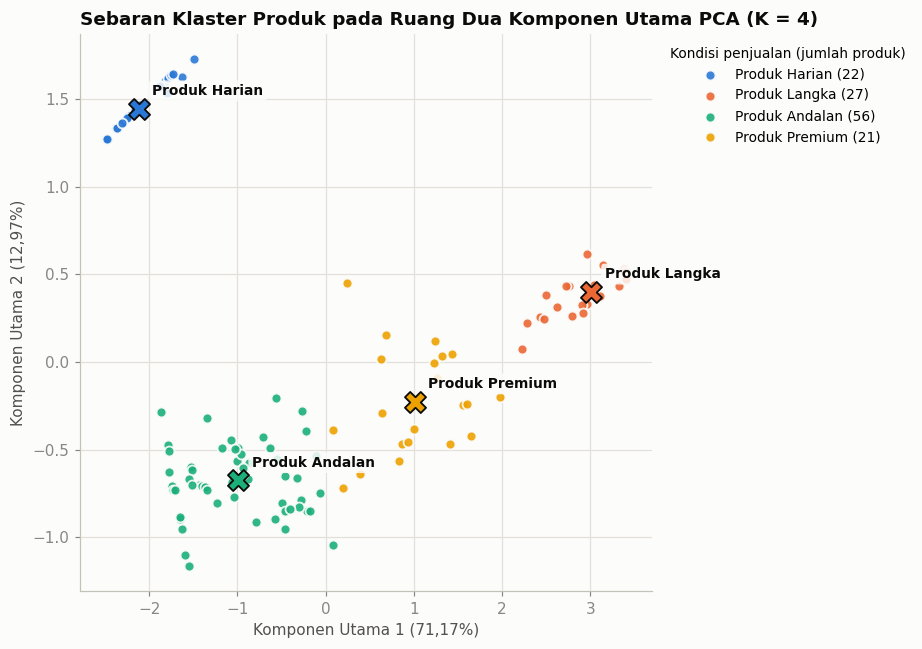

Tanda X = centroid (pusat klaster).


In [14]:
fig, ax = plt.subplots(figsize=(8.5, 6))
for i, kondisi in enumerate(URUTAN_KONDISI):
    s = df_lab[df_lab.kondisi_penjualan == kondisi]
    ax.scatter(s.pc1_scaled, s.pc2_scaled, s=42, color=WARNA_KONDISI[kondisi], edgecolor='#fcfcfb', linewidth=1.2,
               alpha=0.9, label=f'{kondisi} ({len(s)})', zorder=2)
for c, (cx, cy) in enumerate(centroid):
    kondisi = nama_klaster[c]
    ax.scatter(cx, cy, marker='X', s=190, color=WARNA_KONDISI[kondisi], edgecolor=TINTA, linewidth=1.2, zorder=4)
    ax.annotate(kondisi, (cx, cy), xytext=(9, 9), textcoords='offset points', fontsize=9, fontweight='bold', color=TINTA,
                bbox=dict(boxstyle='round,pad=0.25', fc='#fcfcfb', ec='none', alpha=0.85), zorder=5)
ax.set_xlabel(f'Komponen Utama 1 ({evr[0]:.2f}%)'.replace('.', ',')); ax.set_ylabel(f'Komponen Utama 2 ({evr[1]:.2f}%)'.replace('.', ','))
ax.legend(title='Kondisi penjualan (jumlah produk)', loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, title_fontsize=9)
ax.set_title(f'Sebaran Klaster Produk pada Ruang Dua Komponen Utama PCA (K = {K_OPT})')
simpan(fig, '07_scatter_pca_klaster')
print('Tanda X = centroid (pusat klaster).')

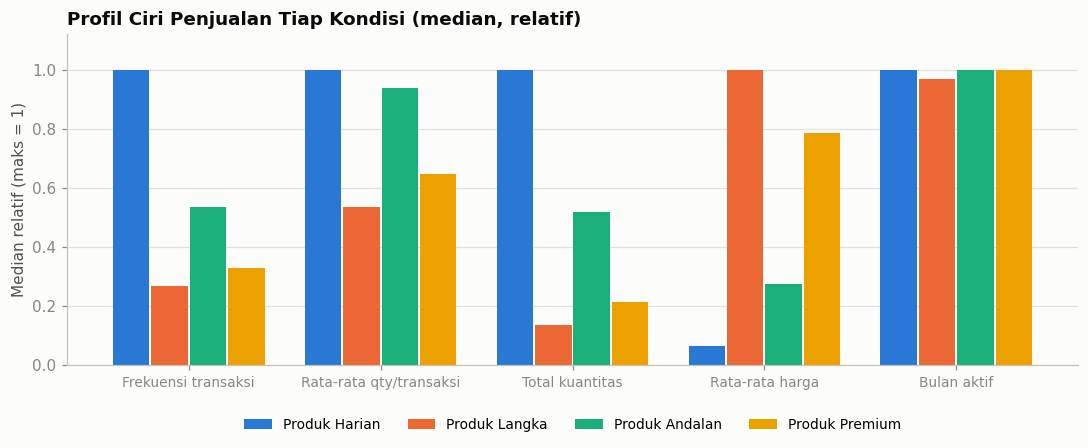

,frekuensi_transaksi,avg_qty_per_transaksi,total_kuantitas,avg_harga,n_bulan_aktif
kondisi_penjualan,,,,,
Produk Harian,1036,7.91,8208,Rp16.385,60
Produk Langka,279,4.25,1115,Rp255.771,58
Produk Andalan,555,7.42,4253,Rp70.579,60
Produk Premium,340,5.12,1758,Rp201.247,60


In [15]:
# Perbandingan median ciri tiap klaster (skala relatif terhadap nilai tertinggi)
median_k = df_lab.groupby('kondisi_penjualan')[FITUR].median().reindex(URUTAN_KONDISI)
relatif = median_k / median_k.max()
fig, ax = plt.subplots(figsize=(10, 4.2))
x = np.arange(len(FITUR)); w = 0.19
for i, kondisi in enumerate(URUTAN_KONDISI):
    ax.bar(x + (i - 1.5) * (w + 0.01), relatif.loc[kondisi], w, color=WARNA_KONDISI[kondisi], label=kondisi)
ax.set_xticks(x, ['Frekuensi transaksi', 'Rata-rata qty/transaksi', 'Total kuantitas', 'Rata-rata harga', 'Bulan aktif'], fontsize=9)
ax.set_ylabel('Median relatif (maks = 1)'); ax.set_ylim(0, 1.12); ax.grid(axis='x', visible=False)
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12), fontsize=9)
ax.set_title('Profil Ciri Penjualan Tiap Kondisi (median, relatif)')
simpan(fig, '08_profil_klaster')
display(median_k.style.format({'avg_qty_per_transaksi': '{:.2f}', 'avg_harga': rupiah}, precision=0))

### 6.1 Stabilitas terhadap titik awal (uji 20 seed)
K-Means dijalankan ulang dengan 20 seed berbeda pada K = 4 untuk melihat pengaruh inisialisasi.

In [16]:
skor_seed = [kmeans.compute_silhouette(df[['pc1_scaled', 'pc2_scaled']].values,
                                       kmeans._run_single_kmeans(df[['pc1_scaled', 'pc2_scaled']].values, 4, seed=s)[0]) for s in range(20)]
stab = pd.Series(skor_seed)
display(pd.DataFrame({'Statistik': ['Rata-rata', 'Standar deviasi', 'Minimum', 'Maksimum', 'Seed 42 (dipakai sistem)'],
                      'Nilai': [stab.mean(), stab.std(ddof=0), stab.min(), stab.max(),
                                kmeans.compute_silhouette(df[['pc1_scaled', 'pc2_scaled']].values, df_km.cluster.values)]})
        .style.hide(axis='index').format({'Nilai': '{:.4f}'}))

Statistik,Nilai
Rata-rata,0.6563
Standar deviasi,0.0106
Minimum,0.6311
Maksimum,0.6608
Seed 42 (dipakai sistem),0.6608


## 7. ABC Analysis
Produk diurutkan berdasarkan total pendapatan; kategori ditentukan dari persentase kumulatif **sebelum** produk
ditambahkan: < 80% → A, < 95% → B, sisanya C (`abc_analysis.classify_abc()`).

In [17]:
abc = abc_analysis.classify_abc(df)
abc['urutan'] = np.arange(1, len(abc) + 1)
ringkas = abc.groupby('prioritas_abc').agg(Jumlah_produk=('produk', 'size'), Pendapatan=('total_pendapatan', 'sum'),
                                           Kontribusi=('persentase_kontribusi', 'sum'))
ringkas['Persen_produk'] = ringkas.Jumlah_produk / len(abc) * 100
display(ringkas[['Jumlah_produk', 'Persen_produk', 'Pendapatan', 'Kontribusi']]
        .style.format({'Persen_produk': '{:.1f}%', 'Pendapatan': rupiah, 'Kontribusi': lambda v: f'{v*100:.2f}%'}))
transisi = abc[abc.prioritas_abc != abc.prioritas_abc.shift()].iloc[1:]
print('Titik transisi antar kategori:')
display(transisi[['urutan', 'produk', 'prioritas_abc', 'persentase_kumulatif']]
        .style.hide(axis='index').format({'persentase_kumulatif': lambda v: f'{v*100:.2f}%'}))
print('10 produk dengan pendapatan tertinggi:')
display(abc.head(10)[['urutan', 'produk', 'total_pendapatan', 'persentase_kontribusi', 'persentase_kumulatif', 'prioritas_abc']]
        .style.hide(axis='index').format({'total_pendapatan': rupiah, 'persentase_kontribusi': lambda v: f'{v*100:.2f}%',
                                          'persentase_kumulatif': lambda v: f'{v*100:.2f}%'}))

,Jumlah_produk,Persen_produk,Pendapatan,Kontribusi
prioritas_abc,,,,
A,77,61.1%,Rp32.993.099.500,80.08%
B,29,23.0%,Rp6.153.501.500,14.94%
C,20,15.9%,Rp2.051.491.500,4.98%


Titik transisi antar kategori:


urutan,produk,prioritas_abc,persentase_kumulatif
78,Aki Kering AHM GTZ6V,B,80.67%
107,Piringan DPN AHM Scoopy New,C,95.44%


10 produk dengan pendapatan tertinggi:


urutan,produk,total_pendapatan,persentase_kontribusi,persentase_kumulatif,prioritas_abc
1,Hendel Rem KTC,Rp1.321.275.500,3.21%,3.21%,A
2,BUSI NGK BP7ES,Rp1.143.412.500,2.78%,5.98%,A
3,MOTUL SCOOTER POWER LE,Rp1.104.380.500,2.68%,8.66%,A
4,Motul SC EXP LE 4T,Rp1.021.535.500,2.48%,11.14%,A
5,MOTUL SCOOTER LE 1 LTR,Rp778.517.500,1.89%,13.03%,A
6,Motul GP MTC 4T,Rp715.540.000,1.74%,14.77%,A
7,FDR TR TL 140/70-13 Blaze Mp,Rp674.610.000,1.64%,16.41%,A
8,Yamalube Super Matic 1 L,Rp649.218.000,1.58%,17.98%,A
9,FDR TR TL 80/90-14 Sport XR Evo,Rp615.863.000,1.49%,19.48%,A
10,BL AHM 80/90-17 KWW,Rp552.501.000,1.34%,20.82%,A


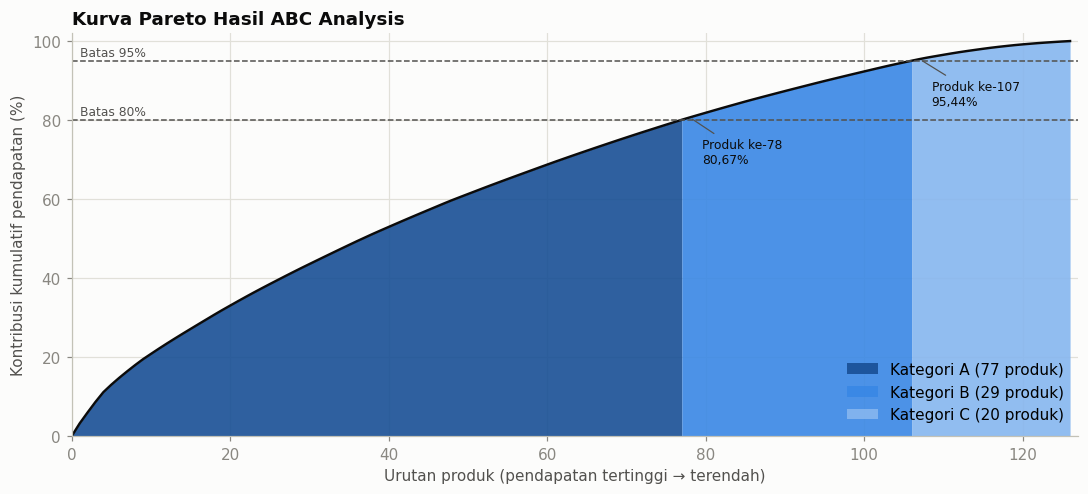

In [18]:
fig, ax = plt.subplots(figsize=(10, 4.6))
kum = abc.persentase_kumulatif.values * 100
x0 = np.r_[0, abc.urutan.values]; y0 = np.r_[0, kum]
for kat in 'ABC':
    idx = np.r_[False, (abc.prioritas_abc == kat).values]
    idx[np.argmax(idx) - 1] = True                      # sambungkan area dengan titik sebelumnya
    ax.fill_between(x0[idx], y0[idx], color=WARNA_ABC[kat], alpha=0.9, linewidth=0,
                    label=f"Kategori {kat} ({(abc.prioritas_abc == kat).sum()} produk)")
ax.plot(x0, y0, color=TINTA, lw=1.6)
for garis, teks in [(80, '80%'), (95, '95%')]:
    ax.axhline(garis, color=TINTA2, lw=1, ls='--')
    ax.text(1, garis + 1.2, f'Batas {teks}', fontsize=8, color=TINTA2)
for _, r in transisi.iterrows():
    ax.annotate(f"Produk ke-{r.urutan}\n{r.persentase_kumulatif*100:.2f}%".replace('.', ','),
                (r.urutan, r.persentase_kumulatif * 100), xytext=(8, -30), textcoords='offset points', fontsize=8, color=TINTA,
                arrowprops=dict(arrowstyle='-', color=TINTA2, lw=0.8))
ax.set_xlim(0, len(abc) + 1); ax.set_ylim(0, 102)
ax.set_xlabel('Urutan produk (pendapatan tertinggi → terendah)'); ax.set_ylabel('Kontribusi kumulatif pendapatan (%)')
ax.legend(loc='lower right'); ax.set_title('Kurva Pareto Hasil ABC Analysis')
simpan(fig, '09_kurva_pareto')

## 8. Integrasi K-Means + ABC: Matriks Segmentasi 4×3 & Rekomendasi

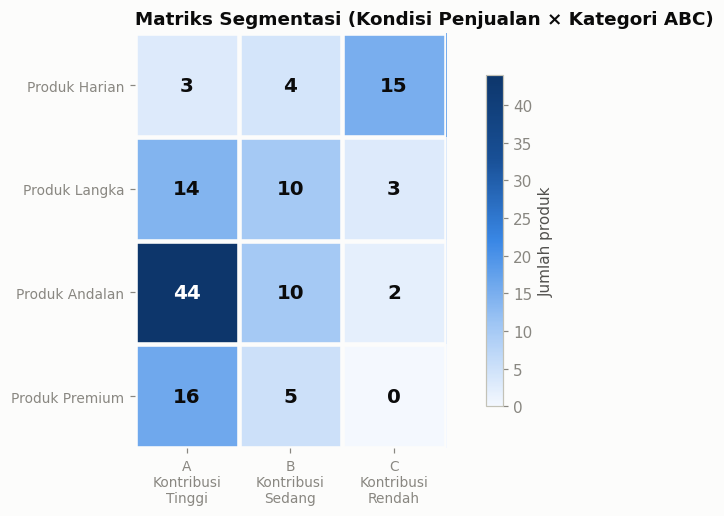

prioritas_abc,A,B,C,Total
kondisi_penjualan,,,,
Produk Harian,3,4,15,22
Produk Langka,14,10,3,27
Produk Andalan,44,10,2,56
Produk Premium,16,5,0,21


In [19]:
gabung = df_lab[['produk', 'kategori', 'kondisi_penjualan', 'total_kuantitas']].merge(
    abc[['produk', 'total_pendapatan', 'prioritas_abc']], on='produk')
gabung = decision_rules.apply_decision_rules(gabung)
matriks = pd.crosstab(gabung.kondisi_penjualan, gabung.prioritas_abc).reindex(index=URUTAN_KONDISI, columns=list('ABC'), fill_value=0)

fig, ax = plt.subplots(figsize=(7.6, 4.8))
im = ax.imshow(matriks.values, cmap=BIRU_SEQ, vmin=0, vmax=matriks.values.max())
ax.set_xticks(range(3), ['A\nKontribusi\nTinggi', 'B\nKontribusi\nSedang', 'C\nKontribusi\nRendah'], fontsize=9)
ax.set_yticks(range(4), URUTAN_KONDISI, fontsize=9); ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
ax.set_xticks(np.arange(-.5, 3), minor=True); ax.set_yticks(np.arange(-.5, 4), minor=True)
ax.grid(which='minor', color='#fcfcfb', linewidth=3); ax.tick_params(which='minor', length=0)
for i in range(4):
    for j in range(3):
        v = matriks.values[i, j]
        ax.text(j, i, v, ha='center', va='center', fontsize=13, fontweight='bold', color='white' if v > 20 else TINTA)
ax.set_title('Matriks Segmentasi (Kondisi Penjualan × Kategori ABC)')
fig.colorbar(im, ax=ax, shrink=0.8, label='Jumlah produk')
simpan(fig, '10_matriks_segmentasi')
display(matriks.assign(Total=matriks.sum(axis=1)))

In [20]:
# Rekomendasi (Tabel 3.5) + contoh produk nyata pada setiap kombinasi
baris = []
for kondisi in URUTAN_KONDISI:
    for kat in 'ABC':
        s = gabung[(gabung.kondisi_penjualan == kondisi) & (gabung.prioritas_abc == kat)].sort_values('total_pendapatan', ascending=False)
        baris.append({'Kondisi': kondisi, 'ABC': kat, 'Jumlah': len(s),
                      'Contoh produk': s.produk.iloc[0] if len(s) else '–',
                      'Rekomendasi': decision_rules.DECISION_MATRIX[kondisi][kat]})
pd.set_option('display.max_colwidth', None)
display(pd.DataFrame(baris).style.hide(axis='index'))

Kondisi,ABC,Jumlah,Contoh produk,Rekomendasi
Produk Harian,A,3,Castrol Pro 2T,"Stok harus selalu tersedia, karena produk sering dibeli."
Produk Harian,B,4,AHM Lampu Kepala,"Jaga stok tetap tersedia, sesuai kebutuhan pelanggan."
Produk Harian,C,15,MOTUL SCOOTER GEAR,"Tetap sediakan stok karena tetap sering dicari, tapi coba naikkan sedikit harganya agar kontribusi pendapatannya meningkat."
Produk Langka,A,14,BL Maxxis 120/70-12 VICTRA,"Tetap sediakan, meskipun jarang dibeli, karena harga barangnya tinggi."
Produk Langka,B,10,Aki Kering AHM GTZ6V,"Sediakan dalam jumlah kecil, karena pembeliannya tidak menentu."
Produk Langka,C,3,Injektor Vario 150 YMMT,"Kurangi jumlah stok, karena jarang dibeli dan nilainya kecil."
Produk Andalan,A,44,BUSI NGK BP7ES,"Utamakan stok, karena produk ini penting dan banyak dibutuhkan pelanggan."
Produk Andalan,B,10,Gasket full seat AHM Supra Fit,"Pertahankan stok, karena produk ini rutin menyumbang pendapatan toko."
Produk Andalan,C,2,Piringan DPN AHM Scoopy New,"Kurangi sedikit stoknya, meski tetap termasuk produk penting."
Produk Premium,A,16,Hendel Rem KTC,"Tetap sediakan stok, tetapi tidak perlu dalam jumlah banyak."


## 9. Validasi Implementasi Manual terhadap Pustaka Pembanding
scikit-learn **hanya dipakai di sini sebagai kunci jawaban**; sistem tetap 100% implementasi manual.
Bagian ini dilewati otomatis bila scikit-learn belum terpasang.

In [21]:
try:
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score, adjusted_rand_score
    from sklearn.preprocessing import StandardScaler
except ImportError:
    print('scikit-learn belum terpasang: pip install scikit-learn')
else:
    Xp = df[['pc1_scaled', 'pc2_scaled']].values
    Z = StandardScaler().fit_transform(X_trans.values)
    pca_sk = PCA(2).fit(Z)
    km_sk = KMeans(K_OPT, n_init=50, random_state=0).fit(Xp)
    val = []
    for k, s_manual in zip(opt['silhouette_data']['k'], opt['silhouette_data']['scores']):
        lab_k = kmeans._run_single_kmeans(Xp, k)[0]
        val.append({'Pengujian': f'Silhouette K={k}', 'Sistem (manual)': s_manual, 'scikit-learn': silhouette_score(Xp, lab_k)})
    val += [{'Pengujian': 'Variansi PC1 (%)', 'Sistem (manual)': evr[0], 'scikit-learn': pca_sk.explained_variance_ratio_[0] * 100},
            {'Pengujian': 'Variansi PC2 (%)', 'Sistem (manual)': evr[1], 'scikit-learn': pca_sk.explained_variance_ratio_[1] * 100},
            {'Pengujian': f'Kesamaan label K={K_OPT} (ARI)', 'Sistem (manual)': 1.0, 'scikit-learn': adjusted_rand_score(df_km.cluster, km_sk.labels_)}]
    v = pd.DataFrame(val); v['Selisih'] = (v['Sistem (manual)'] - v['scikit-learn']).abs()
    v['Hasil'] = np.where(v.Selisih < 1e-6, 'Identik', 'Berbeda')
    display(v.style.hide(axis='index').format({'Sistem (manual)': '{:.6f}', 'scikit-learn': '{:.6f}', 'Selisih': '{:.1e}'}))

Pengujian,Sistem (manual),scikit-learn,Selisih,Hasil
Silhouette K=2,0.605967,0.605967,2.2e-16,Identik
Silhouette K=3,0.654646,0.654646,2.2e-16,Identik
Silhouette K=4,0.660763,0.660763,6.7e-16,Identik
Silhouette K=5,0.626831,0.626831,6.7e-16,Identik
Variansi PC1 (%),71.172798,71.172798,0.0e+00,Identik
Variansi PC2 (%),12.967525,12.967525,0.0e+00,Identik
Kesamaan label K=4 (ARI),1.000000,1.000000,0.0e+00,Identik


## 10. Ringkasan Angka untuk BAB IV

In [22]:
ringkasan = {
    'Baris item penjualan': f"{df.attrs['n_transaksi_setelah_cleaning']:,}",
    'Transaksi (invoice)': f"{df.attrs['n_invoice']:,}",
    'Produk': len(df),
    'Total pendapatan': rupiah(df.total_pendapatan.sum()),
    'Variansi 2 komponen PCA': f"{evr[:2].sum():.2f}%",
    'WCSS K=2..5': ' / '.join(f'{w:.2f}' for w in eval_k.WCSS),
    'Silhouette K=2..5': ' / '.join(f'{s:.4f}' for s in eval_k.Silhouette),
    'K optimal': K_OPT,
    'Distribusi klaster': ', '.join(f"{k}: {v}" for k, v in df_lab.kondisi_penjualan.value_counts().reindex(URUTAN_KONDISI).items()),
    'Distribusi ABC': ', '.join(f"{k}: {v}" for k, v in abc.prioritas_abc.value_counts().sort_index().items()),
    'Kontribusi ABC': ', '.join(f"{k}: {v*100:.2f}%" for k, v in ringkas.Kontribusi.items()),
}
display(pd.Series(ringkasan, name='Nilai').to_frame())
print(f'Semua grafik tersimpan di: {GRAFIK}')

,Nilai
Baris item penjualan,"66,865"
Transaksi (invoice),"24,540"
Produk,126
Total pendapatan,Rp41.198.092.500
Variansi 2 komponen PCA,84.14%
WCSS K=2..5,169.16 / 73.33 / 33.79 / 19.53
Silhouette K=2..5,0.6060 / 0.6546 / 0.6608 / 0.6268
K optimal,4
Distribusi klaster,"Produk Harian: 22, Produk Langka: 27, Produk Andalan: 56, Produk Premium: 21"
Distribusi ABC,"A: 77, B: 29, C: 20"


Semua grafik tersimpan di: /home/claude/ta2/TugasAkhir7smtAstungkarafix/backend/notebooks/grafik
